In [12]:
!pip install opacus

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 362, in run
    resolver = self.make_resolver(
               ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 177, in make_resolver
    return pip._internal.resolution.resolvelib.resolver.Resolver(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", line 58, in __init__
    self.factory = Factory(
                   ^^^^^^^^
  File "/usr/local/lib/py

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from opacus import PrivacyEngine

In [14]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

print("Dataset loaded successfully")

Dataset loaded successfully


In [15]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = Net()
print(model)

Net(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [16]:
optimizer = optim.SGD(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

In [17]:
privacy_engine = PrivacyEngine()

model, optimizer, train_loader = privacy_engine.make_private(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader,
    noise_multiplier=1.0,
    max_grad_norm=1.0
)

print("Differential Privacy Enabled")

Differential Privacy Enabled


In [1]:
import torch
print(torch.cuda.is_available())


True


In [4]:
!pip install opacus

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from opacus import PrivacyEngine

In [6]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

print("Dataset loaded")

Dataset loaded


In [7]:
class Net(nn.Module):
    def __init__(self):
        super(Net,self).__init__()
        self.fc1 = nn.Linear(28*28,128)
        self.fc2 = nn.Linear(128,10)

    def forward(self,x):
        x = x.view(-1,28*28)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = Net()

In [8]:
optimizer = optim.SGD(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

In [9]:
privacy_engine = PrivacyEngine()

model, optimizer, train_loader = privacy_engine.make_private(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader,
    noise_multiplier=1.0,
    max_grad_norm=1.0
)

/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(


In [10]:
for epoch in range(3):
    for data, target in train_loader:

        optimizer.zero_grad()

        output = model(data)
        loss = criterion(output, target)

        loss.backward()
        optimizer.step()

    print("Epoch:", epoch, "Loss:", loss.item())

/tmp/ipykernel_3298/3732162258.py:9: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


Epoch: 0 Loss: 1.8141318559646606


KeyboardInterrupt: 

In [11]:
from torch.utils.data import Subset

small_dataset = Subset(train_dataset, range(2000))
train_loader = DataLoader(small_dataset, batch_size=32, shuffle=True)

In [13]:
from torch.utils.data import Subset

small_dataset = Subset(train_dataset, range(2000))
train_loader = DataLoader(small_dataset, batch_size=32, shuffle=True)

In [14]:
from torch.utils.data import Subset

small_dataset = Subset(train_dataset, range(2000))
train_loader = DataLoader(small_dataset, batch_size=32, shuffle=True)

for epoch in range(1):
    for data, target in train_loader:

        optimizer.zero_grad()

        output = model(data)
        loss = criterion(output, target)

        loss.backward()
        optimizer.step()

    print("Epoch:", epoch, "Loss:", loss.item())

/tmp/ipykernel_3298/917385227.py:14: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


Epoch: 0 Loss: 1.7133209705352783


In [15]:
epsilon = privacy_engine.get_epsilon(delta=1e-5)

print("Privacy budget (ε):", epsilon)

Privacy budget (ε): 0.2243643561166499


In [16]:
correct = 0
total = 0

for data, target in train_loader:
    outputs = model(data)
    _, predicted = torch.max(outputs.data, 1)

    total += target.size(0)
    correct += (predicted == target).sum().item()

accuracy = 100 * correct / total
print("Model Accuracy:", accuracy, "%")

Model Accuracy: 70.6 %


In [19]:
model.train()

GradSampleModule(Net(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
))

In [1]:
!pip install opacus

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from opacus import PrivacyEngine

In [3]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

small_dataset = Subset(train_dataset, range(2000))

train_loader = DataLoader(small_dataset, batch_size=32, shuffle=True)

In [4]:
class Net(nn.Module):
    def __init__(self):
        super(Net,self).__init__()
        self.fc1 = nn.Linear(28*28,128)
        self.fc2 = nn.Linear(128,10)

    def forward(self,x):
        x = x.view(-1,28*28)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = Net()

In [5]:
optimizer = optim.SGD(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

In [6]:
privacy_engine = PrivacyEngine()

model, optimizer, train_loader = privacy_engine.make_private(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader,
    noise_multiplier=1.0,
    max_grad_norm=1.0
)

/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(


In [7]:
model.train()

for epoch in range(3):
    for data, target in train_loader:

        optimizer.zero_grad()

        output = model(data)
        loss = criterion(output, target)

        loss.backward()
        optimizer.step()

    print("Epoch:", epoch, "Loss:", loss.item())

/tmp/ipykernel_6385/4263640376.py:11: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


Epoch: 0 Loss: 2.2593178749084473
Epoch: 1 Loss: 2.2458810806274414
Epoch: 2 Loss: 2.2067067623138428


In [8]:
epsilon = privacy_engine.get_epsilon(delta=1e-5)
print("Privacy budget ε:", epsilon)

Privacy budget ε: 1.4424325259742434


In [9]:
correct = 0
total = 0

for data, target in train_loader:
    outputs = model(data)
    _, predicted = torch.max(outputs.data,1)

    total += target.size(0)
    correct += (predicted == target).sum().item()

print("Accuracy:",100*correct/total,"%")

Accuracy: 43.2994923857868 %


In [10]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()

        self.conv1 = nn.Conv2d(1,16,3)
        self.conv2 = nn.Conv2d(16,32,3)

        self.fc1 = nn.Linear(32*24*24,128)
        self.fc2 = nn.Linear(128,10)

    def forward(self,x):

        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))

        x = x.view(x.size(0),-1)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [12]:
losses = []

In [14]:
privacy_engine = PrivacyEngine()

model, optimizer, train_loader = privacy_engine.make_private(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader,
    noise_multiplier=1.0,
    max_grad_norm=1.0
)

In [1]:
!pip install opacus

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

from opacus import PrivacyEngine

In [3]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

small_dataset = Subset(train_dataset, range(2000))

train_loader = DataLoader(small_dataset, batch_size=32, shuffle=True)

In [4]:
class Net(nn.Module):
    def __init__(self):
        super(Net,self).__init__()

        self.fc1 = nn.Linear(28*28,128)
        self.fc2 = nn.Linear(128,10)

    def forward(self,x):
        x = x.view(-1,28*28)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = Net()

In [5]:
optimizer = optim.SGD(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

In [6]:
privacy_engine = PrivacyEngine()

model, optimizer, train_loader = privacy_engine.make_private(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader,
    noise_multiplier=1.0,
    max_grad_norm=1.0
)

/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(


In [7]:
losses = []

model.train()

for epoch in range(3):
    for data, target in train_loader:

        optimizer.zero_grad()

        output = model(data)
        loss = criterion(output, target)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    print("Epoch:",epoch,"Loss:",loss.item())

/tmp/ipykernel_9032/3940904870.py:13: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


Epoch: 0 Loss: 2.2885210514068604
Epoch: 1 Loss: 2.264371633529663
Epoch: 2 Loss: 2.1978342533111572


In [8]:
epsilon = privacy_engine.get_epsilon(delta=1e-5)
print("Privacy budget ε:",epsilon)

Privacy budget ε: 1.4424325259742434


In [9]:
correct = 0
total = 0

for data, target in train_loader:
    outputs = model(data)
    _, predicted = torch.max(outputs.data,1)

    total += target.size(0)
    correct += (predicted == target).sum().item()

print("Accuracy:",100*correct/total,"%")

Accuracy: 40.76246334310851 %


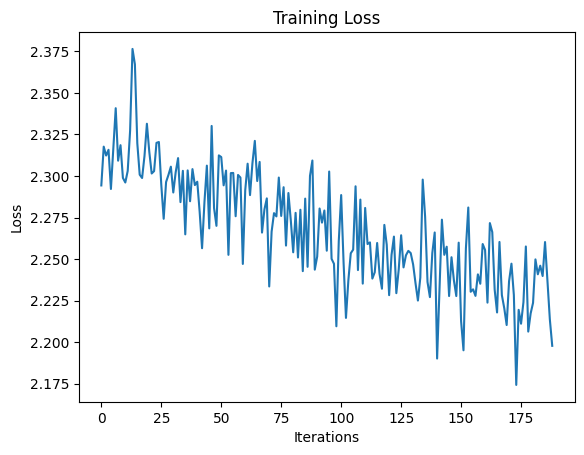

In [10]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

In [11]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()

        self.conv1 = nn.Conv2d(1,16,3)
        self.conv2 = nn.Conv2d(16,32,3)
        self.pool = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(32*12*12,128)
        self.fc2 = nn.Linear(128,10)

    def forward(self,x):

        x = torch.relu(self.conv1(x))
        x = self.pool(x)

        x = torch.relu(self.conv2(x))
        x = self.pool(x)

        x = x.view(x.size(0),-1)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [12]:
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(test_dataset,batch_size=64)

In [13]:
noise_values = [0.5,1.0,2.0]

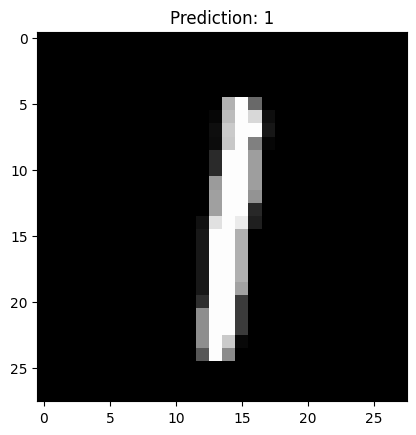

In [14]:
import matplotlib.pyplot as plt

image = data[0]
plt.imshow(image.squeeze(),cmap="gray")
plt.title("Prediction: {}".format(predicted[0].item()))
plt.show()

In [15]:
torch.save(model.state_dict(),"dp_model.pth")